In [ ]:
# STRUCTURAL HEALTH MONITORING (SHM) — BRIDGE DIGITAL TWIN
# Full Pipeline: EDA → Preprocessing → Clustering →
#                Isolation Forest → Random Forest → Comparison
#                → Maintenance Decision Engine
# Features: 13 domain-selected by civil engineering judgment

# SECTION 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)

# SECTION 2 — LOAD DATASET

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/bridge_digital_twin_dataset.csv")

# Parse timestamp and sort chronologically (critical for time-series)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print("Dataset Shape:", df.shape)
df.head()

# SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)

Mounted at /content/drive
Dataset Shape: (43200, 54)


,Timestamp,Strain_microstrain,Deflection_mm,Vibration_ms2,Tilt_deg,Displacement_mm,Crack_Propagation_mm,Corrosion_Level_percent,Cable_Member_Tension_kN,Bearing_Joint_Forces_kN,...,Soil_Saturation_percent,Landslide_Ground_Movement,Simulated_Slope_Displacement_mm,High_Winds_Storms,Simulated_Wind_Load_Pressure_kPa,Abnormal_Traffic_Load_Surges,Simulated_Localized_Stress_Index,Energy_Harvesting_Potential_W,Estimated_Repair_Cost_USD_incremental,Carbon_Footprint_tCO2e_incremental
0,2023-01-01 00:00:00,NaN,12.663104,1.275955,0.587340,22.576518,-0.000083,0.002910,404.394906,233.052345,...,9.888758,0.0,0.022592,0.0,0.211946,0.0,0.215354,0.081403,1.343588,0.001348
1,2023-01-01 00:01:00,599.936448,12.235297,0.716857,0.657122,21.202649,0.000092,0.004601,367.821051,237.545735,...,9.920331,0.0,0.014647,0.0,0.231188,0.0,0.218747,0.107097,1.397207,0.001299
2,2023-01-01 00:02:00,573.878472,12.447144,0.834753,0.615011,NaN,-0.000377,0.005115,402.393742,239.164832,...,NaN,0.0,0.000000,0.0,0.199192,0.0,0.213449,0.141938,1.318876,0.001378
3,2023-01-01 00:03:00,550.457302,12.554883,1.004917,0.617999,21.551945,-0.000646,0.005505,356.024238,237.645586,...,43.526026,0.0,0.000000,0.0,0.198359,0.0,0.208190,0.192431,1.351773,0.001379
4,2023-01-01 00:04:00,572.829960,12.598818,1.176253,0.633534,21.711292,0.000247,-0.003415,413.338280,232.310381,...,44.138185,0.0,0.000000,0.0,0.188110,0.0,0.261240,0.261609,NaN,0.001267


### 3.1 Dataset Info

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 54 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Timestamp                              43200 non-null  datetime64[ns]
 1   Strain_microstrain                     41379 non-null  float64       
 2   Deflection_mm                          41467 non-null  float64       
 3   Vibration_ms2                          41478 non-null  float64       
 4   Tilt_deg                               41447 non-null  float64       
 5   Displacement_mm                        41473 non-null  float64       
 6   Crack_Propagation_mm                   41494 non-null  float64       
 7   Corrosion_Level_percent                41531 non-null  float64       
 8   Cable_Member_Tension_kN                41459 non-null  float64       
 9   Bearing_Joint_Forces_kN                41515 non-null  float6

,Timestamp,Strain_microstrain,Deflection_mm,Vibration_ms2,Tilt_deg,Displacement_mm,Crack_Propagation_mm,Corrosion_Level_percent,Cable_Member_Tension_kN,Bearing_Joint_Forces_kN,...,Soil_Saturation_percent,Landslide_Ground_Movement,Simulated_Slope_Displacement_mm,High_Winds_Storms,Simulated_Wind_Load_Pressure_kPa,Abnormal_Traffic_Load_Surges,Simulated_Localized_Stress_Index,Energy_Harvesting_Potential_W,Estimated_Repair_Cost_USD_incremental,Carbon_Footprint_tCO2e_incremental
count,43200,41379.000000,41467.000000,41478.000000,41447.000000,41473.000000,41494.000000,41531.000000,41459.000000,41515.000000,...,41453.000000,41435.000000,41499.000000,41442.000000,41476.000000,41437.000000,41482.000000,41471.000000,41429.000000,41476.000000
mean,2023-01-15 23:59:30,851.950836,15.145403,1.339495,0.756122,22.703596,0.015036,0.149950,476.054924,276.967988,...,25.467336,0.000072,0.764185,0.002099,0.199037,0.003186,0.461482,1.367458,313.237508,0.001852
min,2023-01-01 00:00:00,363.529753,6.889697,0.637735,0.476074,18.964441,-0.001531,-0.010256,334.045442,205.758025,...,9.888758,0.000000,0.000000,0.000000,0.113733,0.000000,0.149282,0.081403,0.989533,0.000901
25%,2023-01-08 11:59:45,618.866446,12.447132,1.000030,0.667321,21.387484,0.007511,0.074979,396.924817,237.447819,...,10.001720,0.000000,0.375525,0.000000,0.157449,0.000000,0.224376,0.510641,1.518210,0.001470
50%,2023-01-15 23:59:30,734.476653,14.986160,1.198123,0.724295,22.361439,0.015024,0.150101,447.899673,260.075977,...,31.420815,0.000000,0.749704,0.000000,0.189452,0.000000,0.375616,0.782173,1.699154,0.001670
75%,2023-01-23 11:59:15,1072.661680,17.090508,1.532924,0.832503,23.985103,0.022526,0.224839,556.362810,318.127839,...,40.644940,0.000000,1.123895,0.000000,0.228776,0.000000,0.698968,1.278369,1.949163,0.002218
max,2023-01-30 23:59:00,4074.893156,30.389080,15.086480,1.522738,27.630262,0.519706,0.312679,844.862138,423.909686,...,68.376629,1.000000,63.736106,1.000000,2.000000,1.000000,1.000000,112.494785,50014.211024,0.003920
std,NaN,351.908310,3.824032,0.979641,0.142167,1.627841,0.009338,0.086731,91.773467,45.590840,...,15.769136,0.008509,0.808539,0.045771,0.088777,0.056351,0.270107,6.316389,3934.070479,0.000566


### 3.2 Missing Values

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
Vibration_Anomaly_Location               34155
Strain_microstrain                        1821
Humidity_percent                          1783
Estimated_Repair_Cost_USD_incremental     1771
Wind_Direction_deg                        1768
Landslide_Ground_Movement                 1765
Abnormal_Traffic_Load_Surges              1763
High_Winds_Storms                         1758
Vehicle_Load_tons                         1756
Localized_Strain_Hotspot                  1754
Tilt_deg                                  1753
Soil_Saturation_percent                   1747
Electrical_Resistance_ohms                1746
Traffic_Volume_vph                        1744
Probability_of_Failure_PoF                1744
Flood_Event_Flag                          1743
Temperature_C                             1743
Cable_Member_Tension_kN                   1741
Air_Quality_Index_AQI                     1739
SHI_Predicted_30d_Ahead                   1738
Visual_Analysis_Defect_Score   

### 3.3 Correlation Heatmap (numeric only)

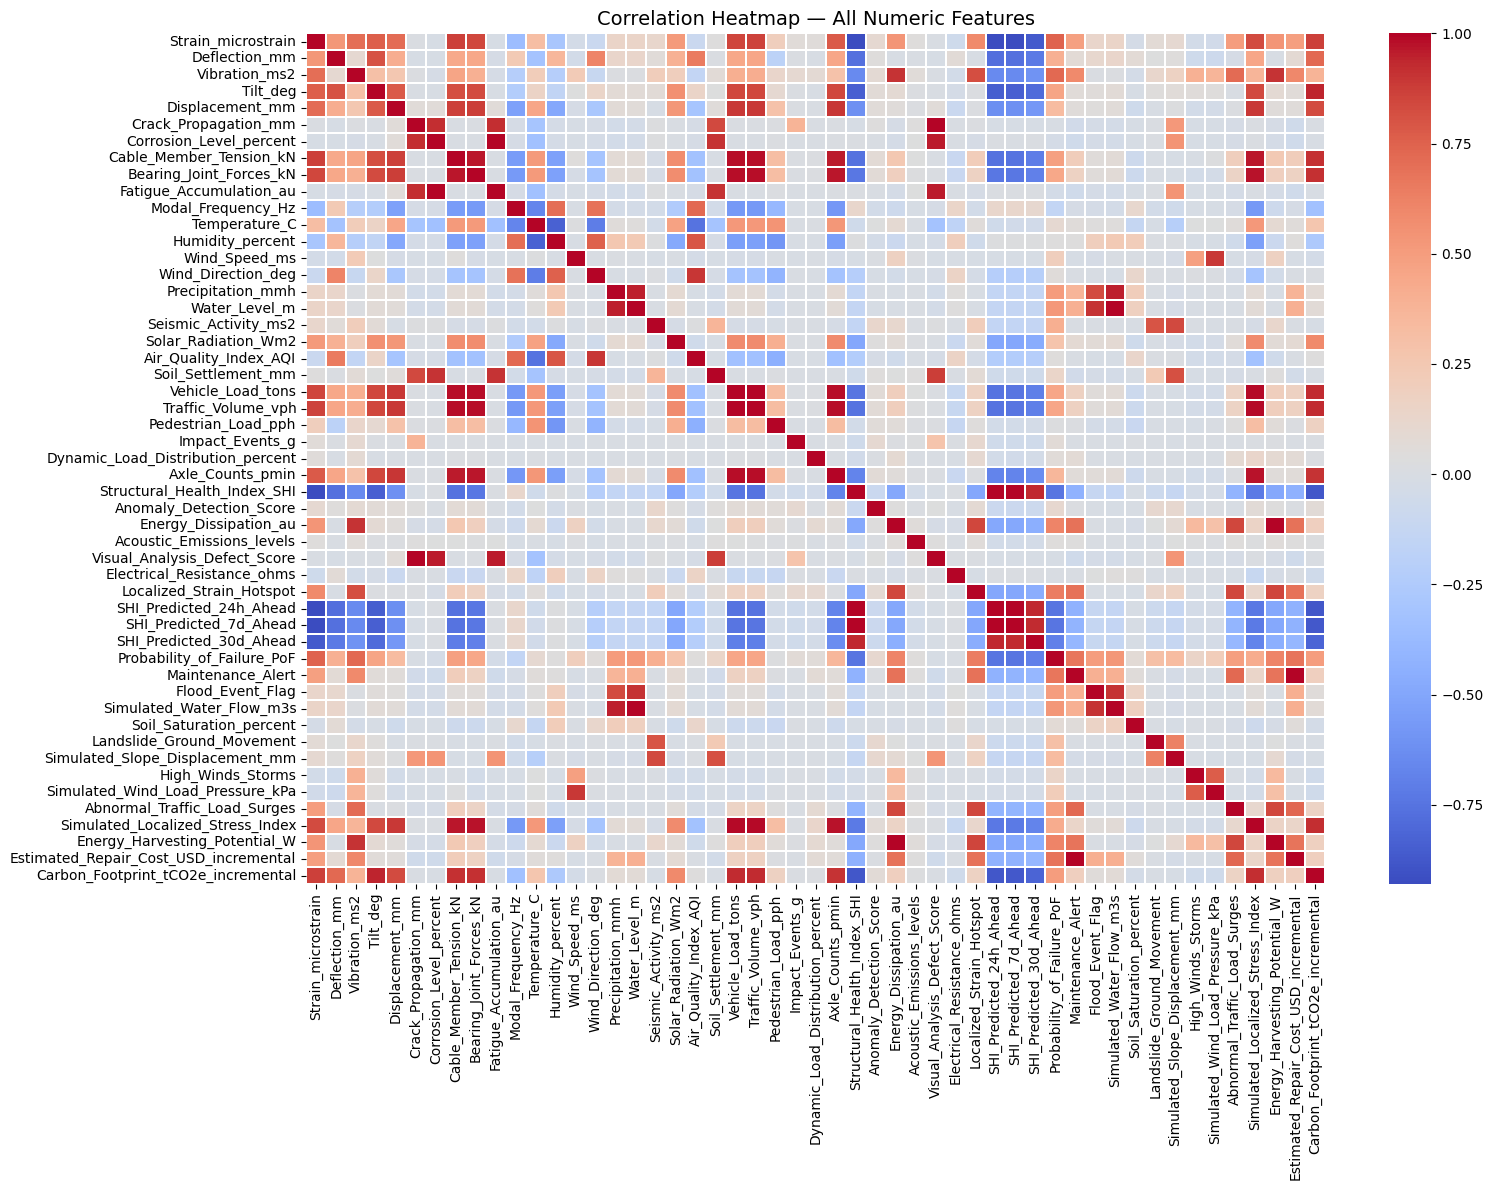

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            cmap='coolwarm', linewidths=0.3, annot=False)
plt.title("Correlation Heatmap — All Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Feature Distributions

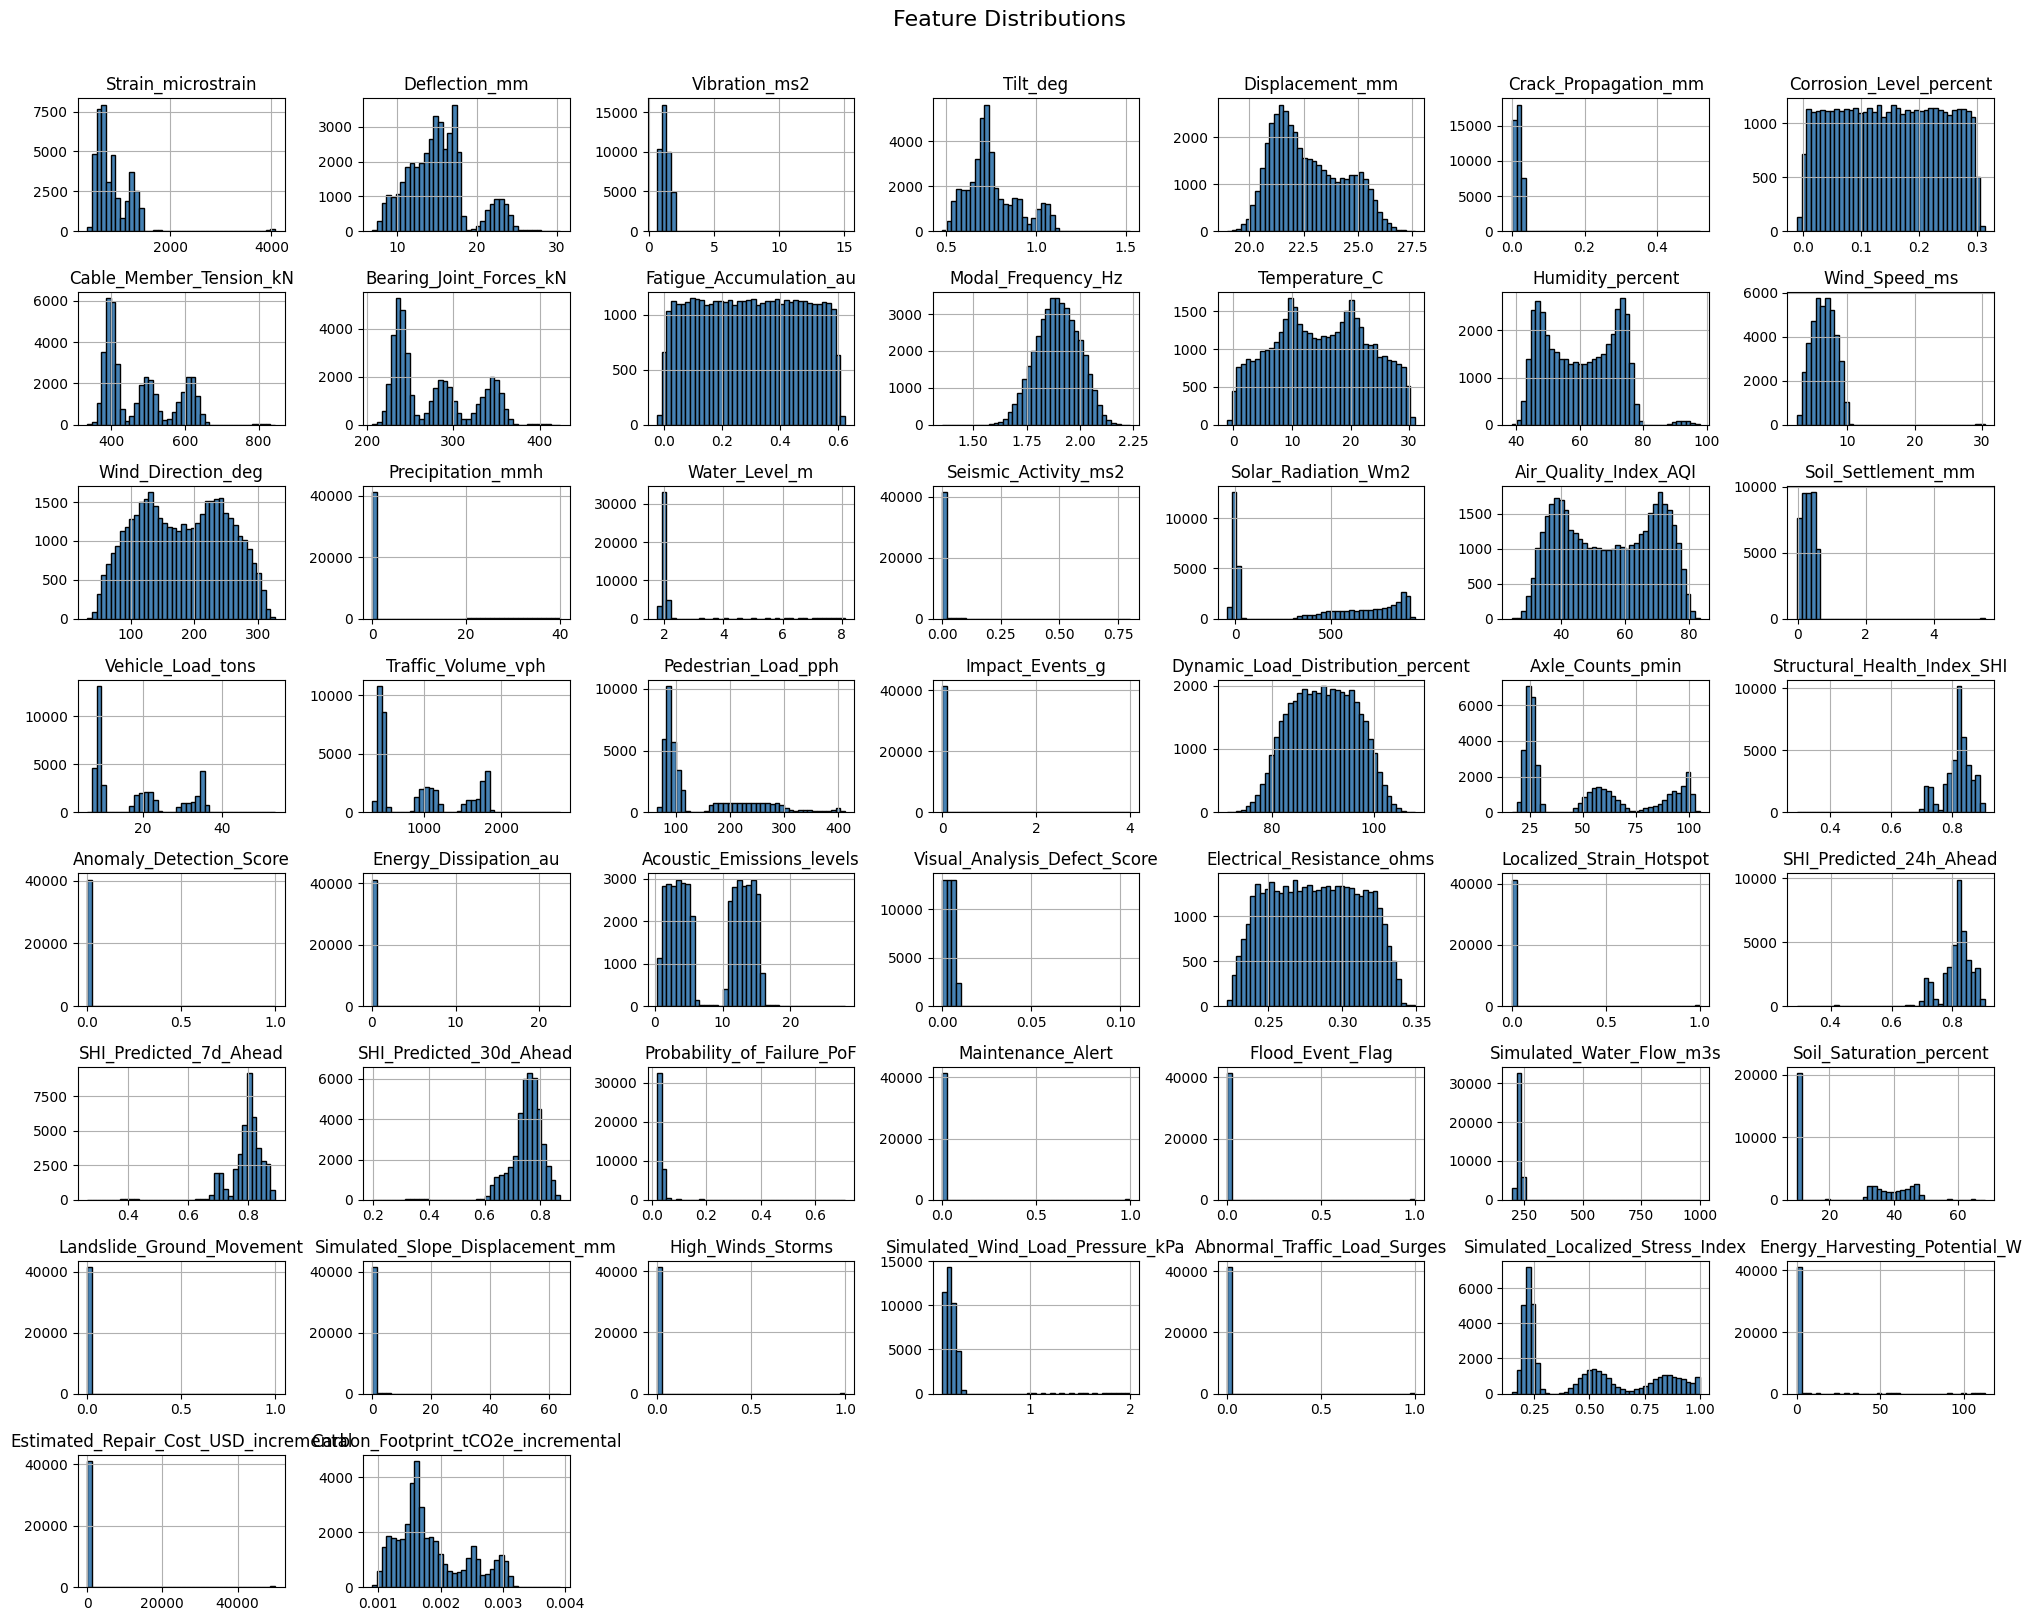

In [ ]:
df.select_dtypes(include=np.number).hist(
    figsize=(20, 16), bins=40, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Boxplot — Outlier Detection

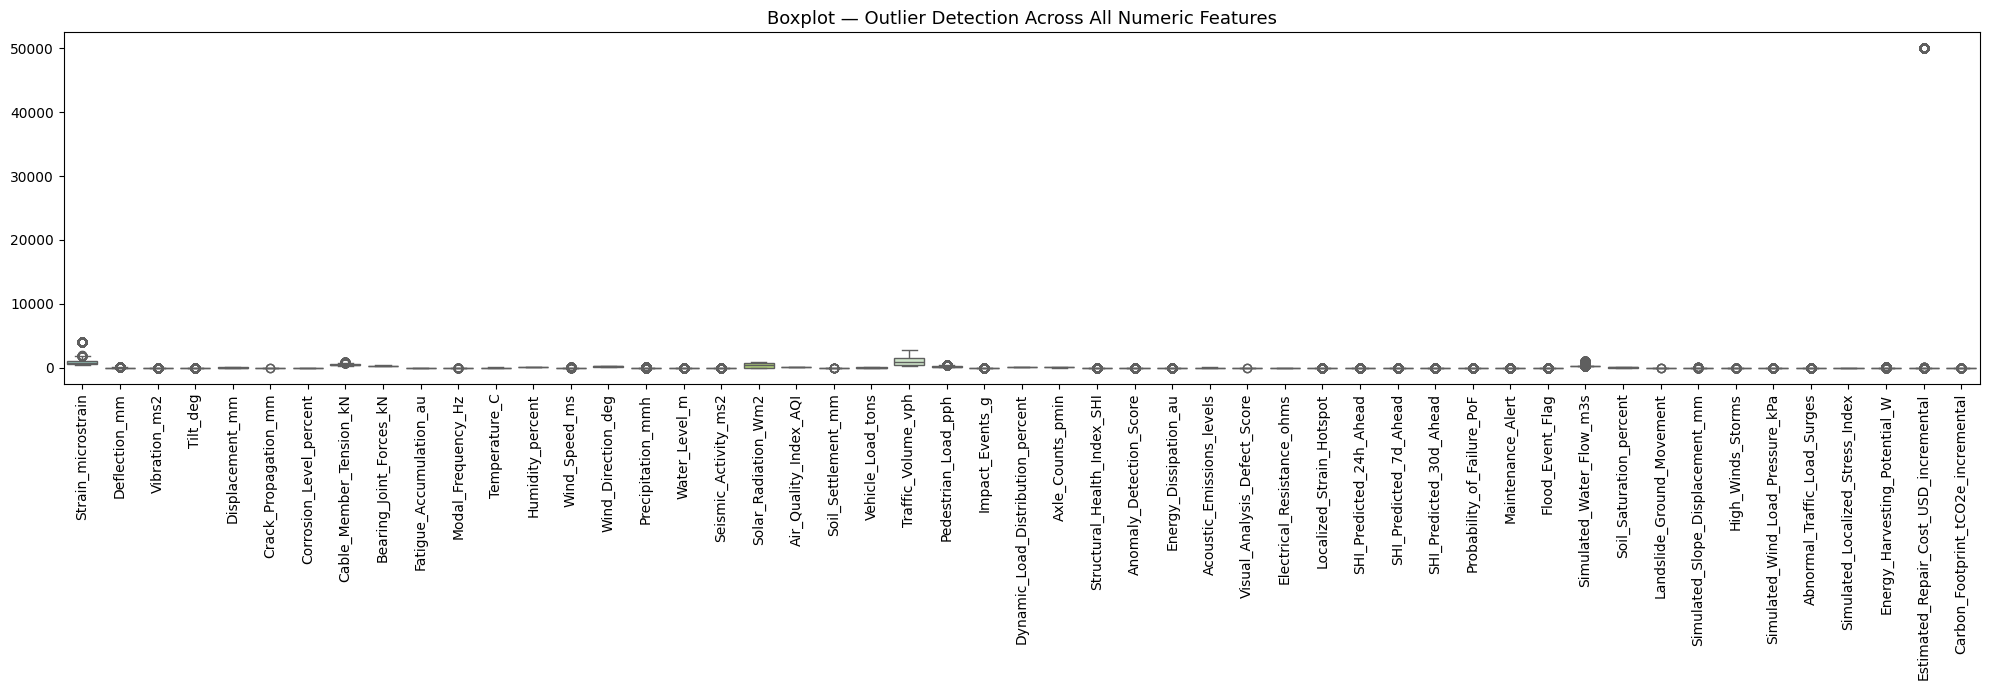

In [ ]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=df.select_dtypes(include=np.number), palette='Set3')
plt.xticks(rotation=90)
plt.title("Boxplot — Outlier Detection Across All Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 Structural Health Index Over Time

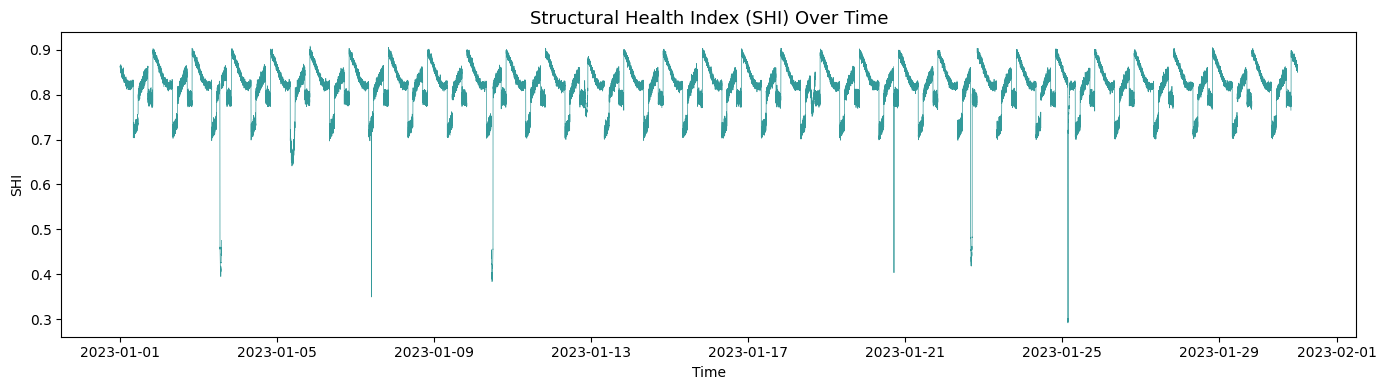

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df['Timestamp'], df['Structural_Health_Index_SHI'],
         linewidth=0.5, color='teal', alpha=0.8)
plt.title("Structural Health Index (SHI) Over Time", fontsize=13)
plt.xlabel("Time")
plt.ylabel("SHI")
plt.tight_layout()
plt.show()

### 3.7 Probability of Failure Over Time

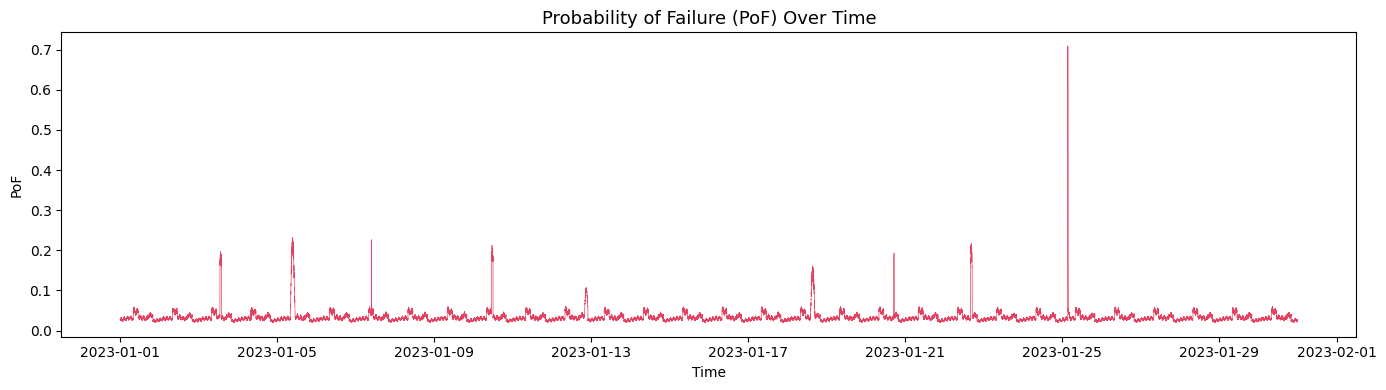

  13 DOMAIN-SELECTED FEATURES FOR ALL MODELS

  [Structural Response]
    • Strain_microstrain
    • Deflection_mm
    • Tilt_deg
    • Displacement_mm
    • Crack_Propagation_mm
    • Cable_Member_Tension_kN

  [Deterioration]
    • Corrosion_Level_percent

  [Loading]
    • Vehicle_Load_tons
    • Traffic_Volume_vph

  [Environmental]
    • Vibration_ms2
    • Wind_Speed_ms
    • Seismic_Activity_ms2

  [Foundation]
    • Soil_Settlement_mm


In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df['Timestamp'], df['Probability_of_Failure_PoF'],
         linewidth=0.5, color='crimson', alpha=0.8)
plt.title("Probability of Failure (PoF) Over Time", fontsize=13)
plt.xlabel("Time")
plt.ylabel("PoF")
plt.tight_layout()
plt.show()

# SECTION 4 — FEATURE DEFINITION (DOMAIN-SELECTED, 13 FEATURES)
# Features chosen based on civil engineering relevance:
#   Structural  : Strain, Deflection, Tilt, Displacement, Crack, Cable Tension
#   Deterioration: Corrosion
#   Loading     : Vehicle Load, Traffic Volume
#   Environmental: Wind Speed, Seismic Activity
#   Foundation  : Soil Settlement

features = [
    # --- Structural response ---
    'Strain_microstrain',           # Core stress indicator
    'Deflection_mm',                # Direct deformation
    'Tilt_deg',                     # Structural inclination
    'Displacement_mm',              # Settlement / movement
    'Crack_Propagation_mm',         # Material degradation
    'Cable_Member_Tension_kN',      # Load-bearing member health
    # --- Deterioration ---
    'Corrosion_Level_percent',      # Long-term material loss
    # --- Loading ---
    'Vehicle_Load_tons',            # Primary live load
    'Traffic_Volume_vph',           # Load frequency
    # --- Environmental ---
    'Vibration_ms2',                # Dynamic response to loads/wind
    'Wind_Speed_ms',                # Wind-induced forcing
    'Seismic_Activity_ms2',         # Ground motion impact
    # --- Foundation ---
    'Soil_Settlement_mm',           # Foundation movement
]

print("=" * 55)
print("  13 DOMAIN-SELECTED FEATURES FOR ALL MODELS")
print("=" * 55)
categories = {
    'Structural Response' : features[0:6],
    'Deterioration'       : features[6:7],
    'Loading'             : features[7:9],
    'Environmental'       : features[9:12],
    'Foundation'          : features[12:13],
}
for cat, feats in categories.items():
    print(f"\n  [{cat}]")
    for f in feats:
        print(f"    • {f}")
print("=" * 55)

# SECTION 5 — DATA PREPROCESSING

X = df[features].copy()

### 5.1 Handle Missing Values (ffill → bfill for timeseries)

In [ ]:
# Uses previous valid sensor reading — far better than mean for time-series
X = X.ffill().bfill()

print(f"Missing values after imputation: {X.isnull().sum().sum()}")

Missing values after imputation: 0


### 5.2 Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Wrap in DataFrame to preserve index (fixes X_test.index bug)
X_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

### 5.3 Distributions of the 13 Selected Features

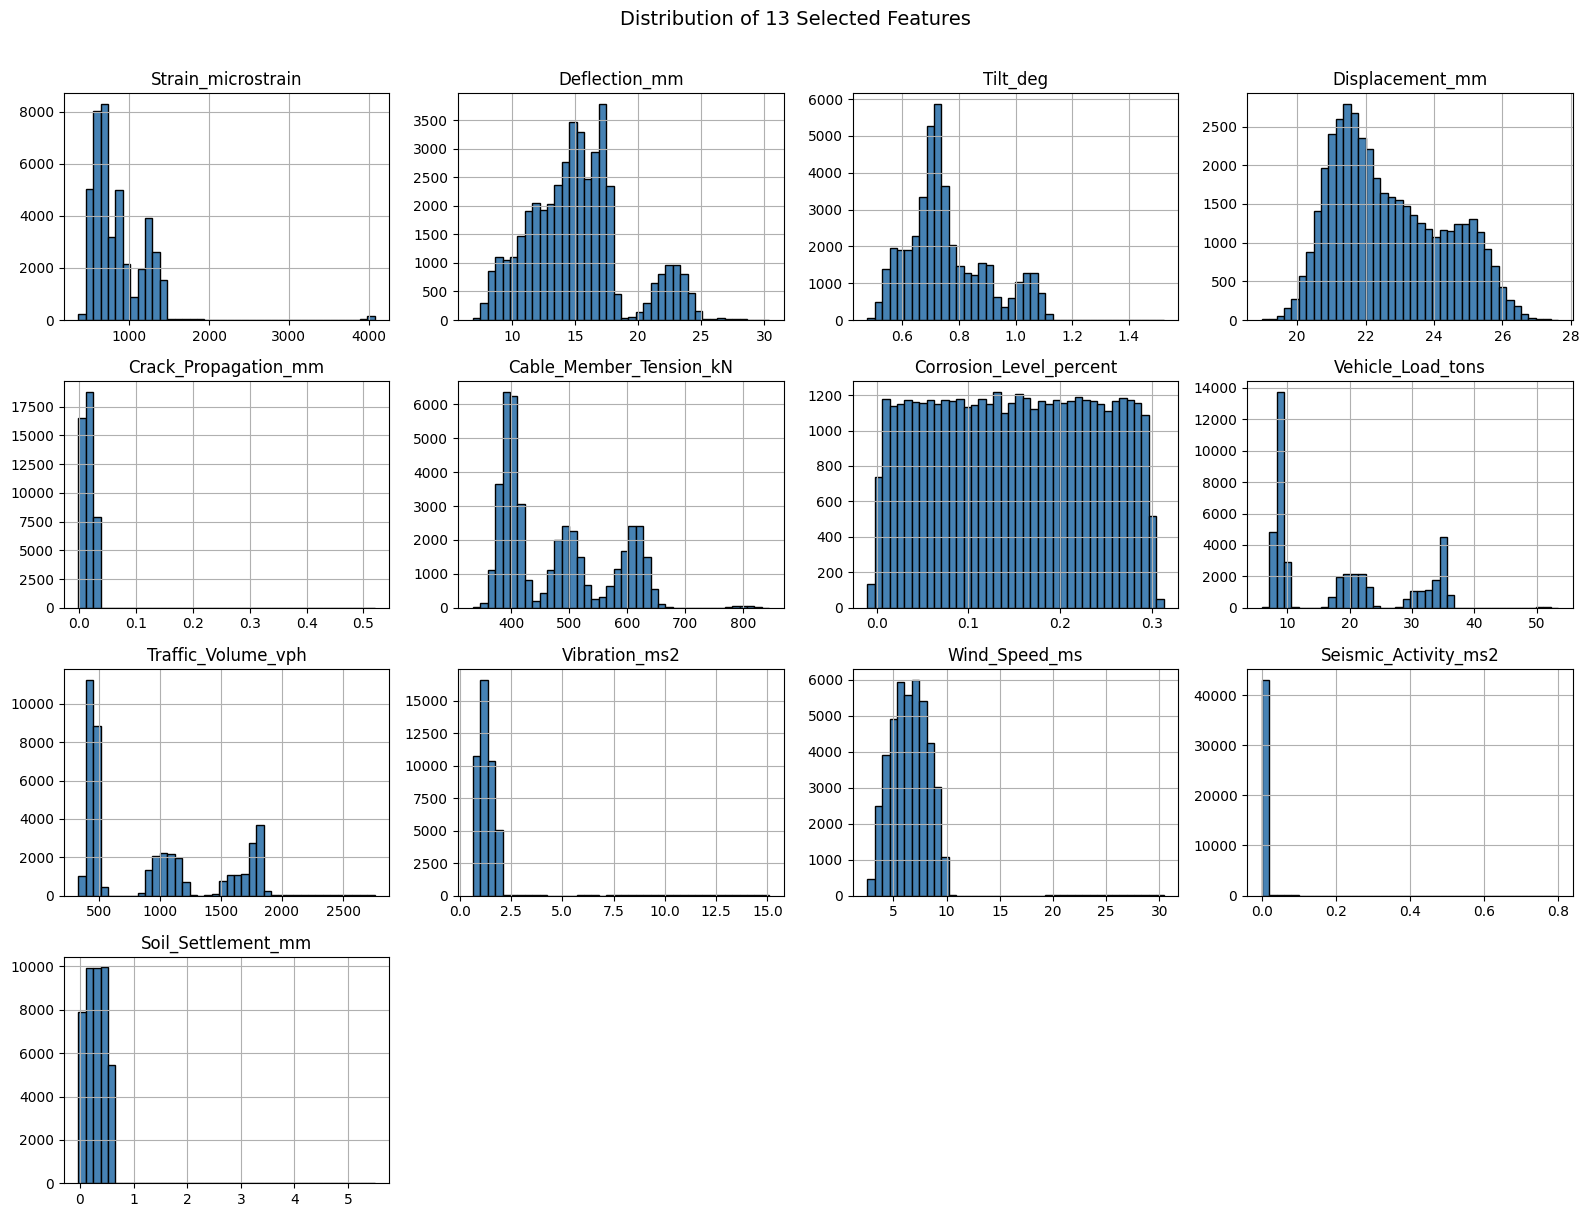

In [ ]:
X.hist(figsize=(16, 12), bins=40, color='steelblue', edgecolor='black')
plt.suptitle("Distribution of 13 Selected Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Correlation Heatmap — Selected Features Only

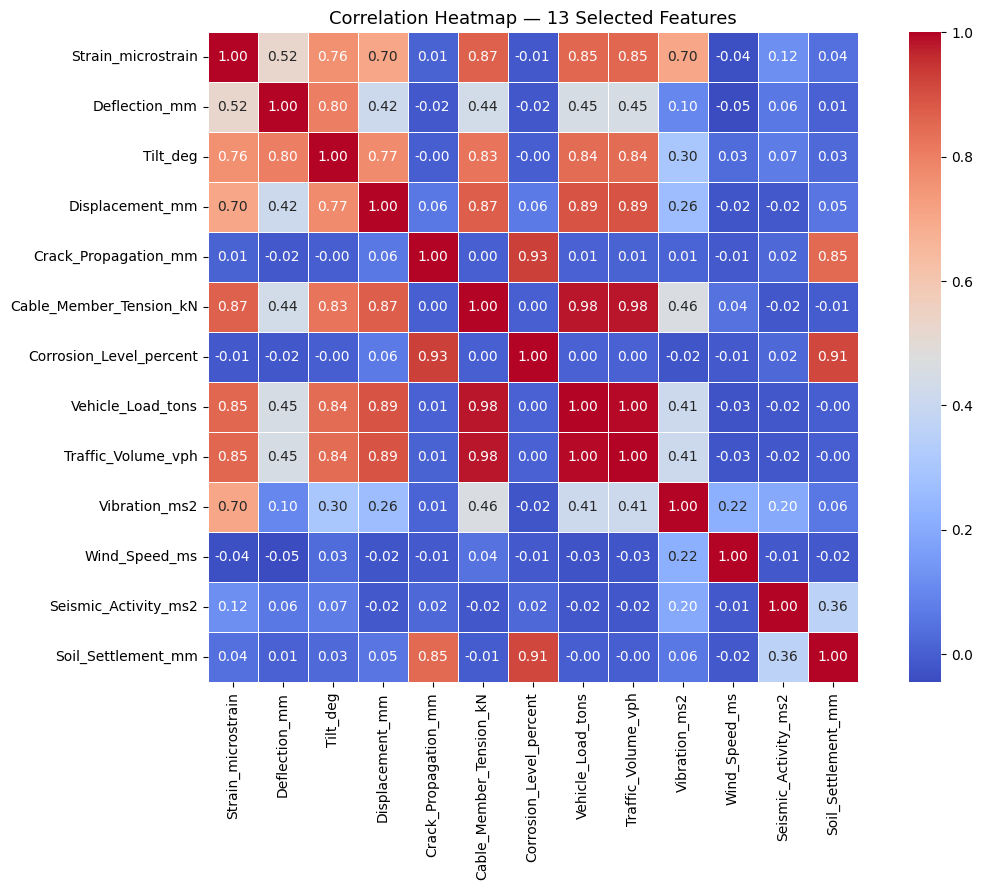

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap — 13 Selected Features", fontsize=13)
plt.tight_layout()
plt.show()

# SECTION 6 — K-MEANS CLUSTERING

### 6.1 Elbow Method

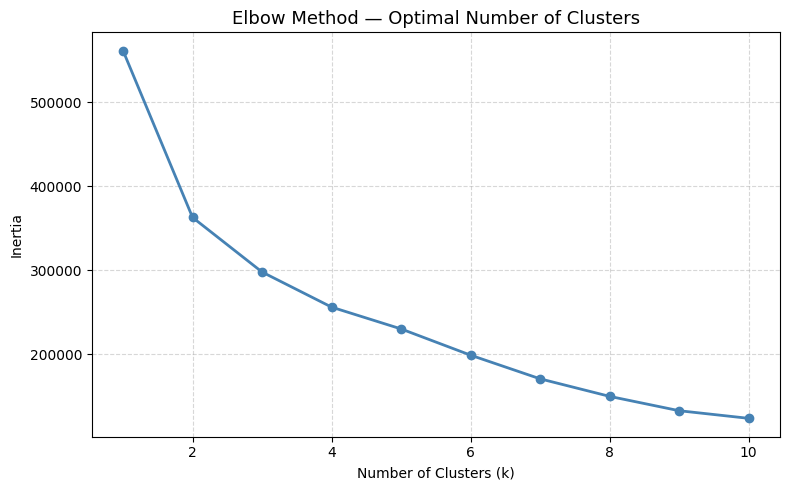

In [ ]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters", fontsize=13)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 6.2 Apply KMeans (k=3: healthy / moderate stress / critical)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters by their mean SHI (highest SHI = healthiest)
shi_by_cluster = df.groupby('Cluster')['Structural_Health_Index_SHI'].mean().sort_values(ascending=False)
cluster_name_map = {
    shi_by_cluster.index[0]: 'Healthy',
    shi_by_cluster.index[1]: 'Moderate Stress',
    shi_by_cluster.index[2]: 'Critical',
}
df['Cluster_Label'] = df['Cluster'].map(cluster_name_map)

print("Cluster distribution:")
print(df['Cluster_Label'].value_counts())

Cluster distribution:
Cluster_Label
Healthy            16038
Moderate Stress    15968
Critical           11194
Name: count, dtype: int64


### 6.3 Mean Feature Values per Cluster


Mean feature values per cluster:
                 Strain_microstrain  Deflection_mm  Tilt_deg  Displacement_mm  \
Cluster_Label                                                                   
Critical                   1310.330         18.605     0.955           24.893   
Healthy                     688.822         13.954     0.688           21.840   
Moderate Stress             695.035         13.911     0.686           22.032   

                 Crack_Propagation_mm  Cable_Member_Tension_kN  \
Cluster_Label                                                    
Critical                        0.015                  609.983   
Healthy                         0.007                  429.080   
Moderate Stress                 0.023                  429.523   

                 Corrosion_Level_percent  Vehicle_Load_tons  \
Cluster_Label                                                 
Critical                           0.150             33.503   
Healthy                            0.075

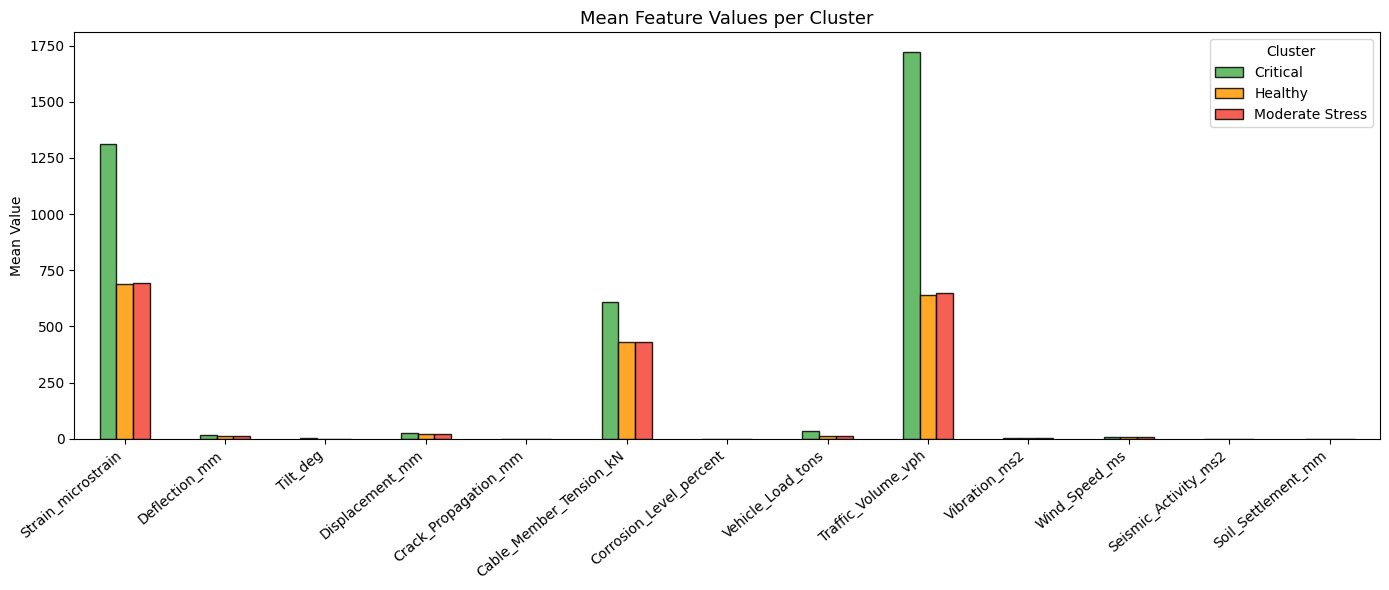

PCA explained variance: PC1=45.2%, PC2=21.8%


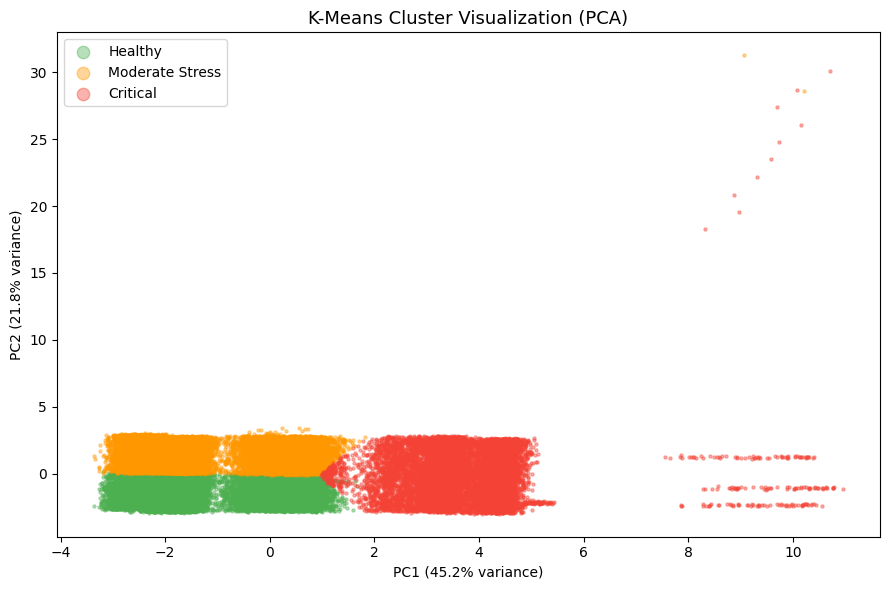

In [ ]:
cluster_profile = df.groupby('Cluster_Label')[features].mean().round(3)
print("\nMean feature values per cluster:")
print(cluster_profile)

cluster_profile.T.plot(kind='bar', figsize=(14, 6),
                       color=['#4CAF50', '#FF9800', '#F44336'],
                       edgecolor='black', alpha=0.85)
plt.title("Mean Feature Values per Cluster", fontsize=13)
plt.ylabel("Mean Value")
plt.xticks(rotation=40, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# SECTION 7 — PCA VISUALIZATION

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PCA explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%")

color_map = {'Healthy': '#4CAF50', 'Moderate Stress': '#FF9800', 'Critical': '#F44336'}

plt.figure(figsize=(9, 6))
for label, color in color_map.items():
    mask = df['Cluster_Label'] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, alpha=0.4, s=5, color=color)
plt.title("K-Means Cluster Visualization (PCA)", fontsize=13)
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

# SECTION 8 — ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)

### 8.1 Contamination Sensitivity Check

In [ ]:
print("Anomaly counts at different contamination levels:")
for cont in [0.01, 0.03, 0.05, 0.08, 0.10]:
    iso_tmp = IsolationForest(n_estimators=100, contamination=cont, random_state=42)
    preds = iso_tmp.fit_predict(X_scaled)
    n = (preds == -1).sum()
    print(f"  contamination={cont:.2f} → {n} anomalies ({n/len(df)*100:.1f}%)")

# Using 5% — reasonable for bridge monitoring
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['Anomaly']        = iso.fit_predict(X_scaled)
df['Anomaly']        = df['Anomaly'].map({1: 0, -1: 1})
df['Anomaly_Score_IF'] = iso.decision_function(X_scaled)

print(f"\nTotal anomalies: {df['Anomaly'].sum()} ({df['Anomaly'].mean()*100:.1f}%)")

Anomaly counts at different contamination levels:
  contamination=0.01 → 432 anomalies (1.0%)
  contamination=0.03 → 1296 anomalies (3.0%)
  contamination=0.05 → 2160 anomalies (5.0%)
  contamination=0.08 → 3456 anomalies (8.0%)
  contamination=0.10 → 4320 anomalies (10.0%)

Total anomalies: 2160 (5.0%)


### 8.2 Anomaly Score Distribution

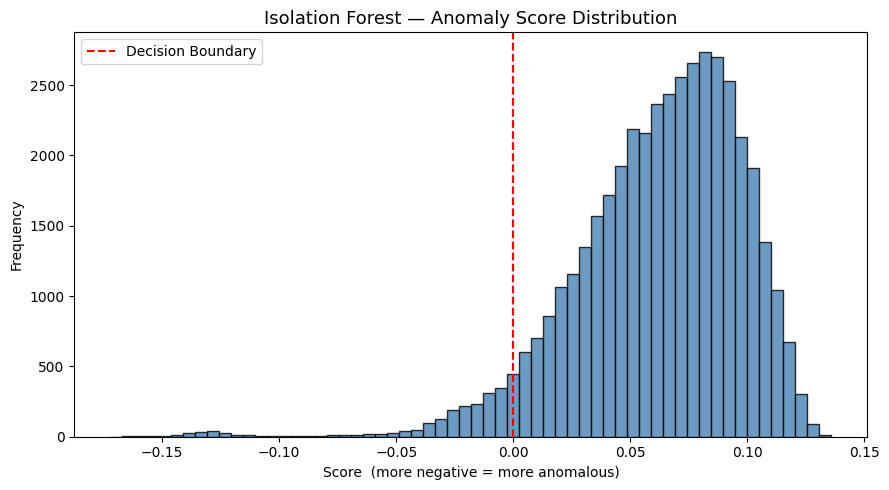

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df['Anomaly_Score_IF'], bins=60,
         color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5,
            label='Decision Boundary')
plt.title("Isolation Forest — Anomaly Score Distribution", fontsize=13)
plt.xlabel("Score  (more negative = more anomalous)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 PCA: Normal vs Anomaly

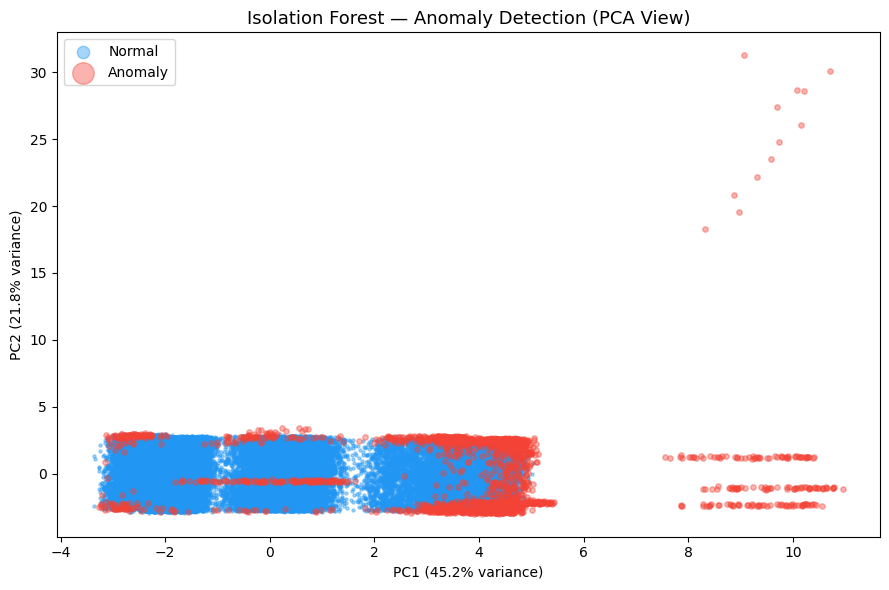

In [ ]:
plt.figure(figsize=(9, 6))
for val, label, color in [(0, 'Normal', '#2196F3'), (1, 'Anomaly', '#F44336')]:
    mask = df['Anomaly'] == val
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, alpha=0.4,
                s=5 if val == 0 else 15, color=color)
plt.title("Isolation Forest — Anomaly Detection (PCA View)", fontsize=13)
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

### 8.4 Anomaly Score Over Time

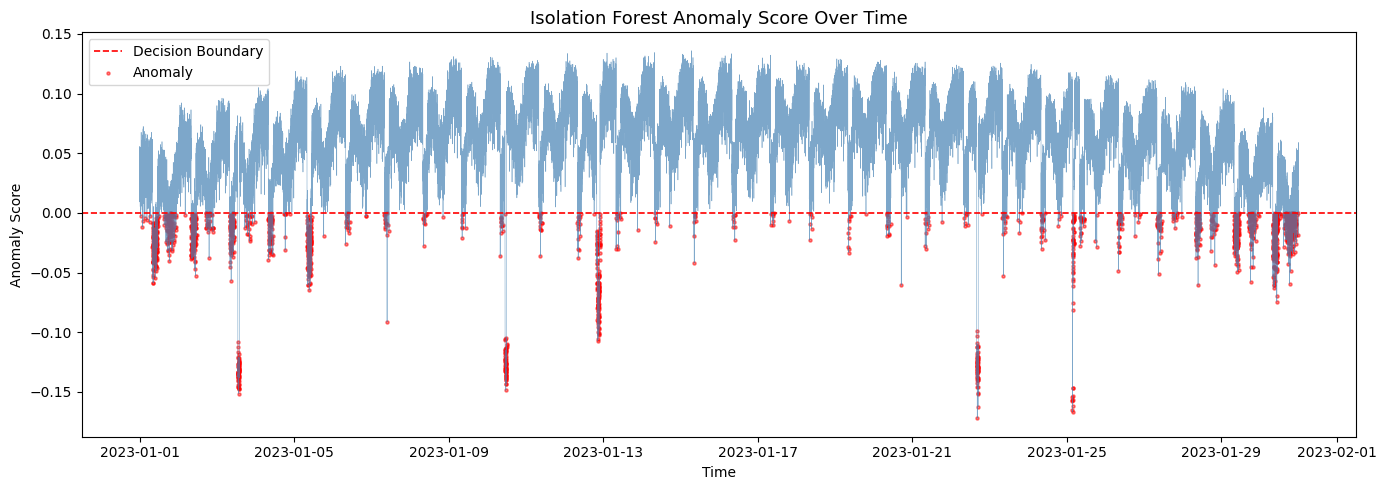

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df['Timestamp'], df['Anomaly_Score_IF'],
         linewidth=0.4, color='steelblue', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2,
            label='Decision Boundary')
anomaly_mask = df['Anomaly'] == 1
plt.scatter(df.loc[anomaly_mask, 'Timestamp'],
            df.loc[anomaly_mask, 'Anomaly_Score_IF'],
            color='red', s=5, alpha=0.5, label='Anomaly')
plt.title("Isolation Forest Anomaly Score Over Time", fontsize=13)
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.legend()
plt.tight_layout()
plt.show()

### 8.5 Normal vs Anomaly — Mean Feature Comparison

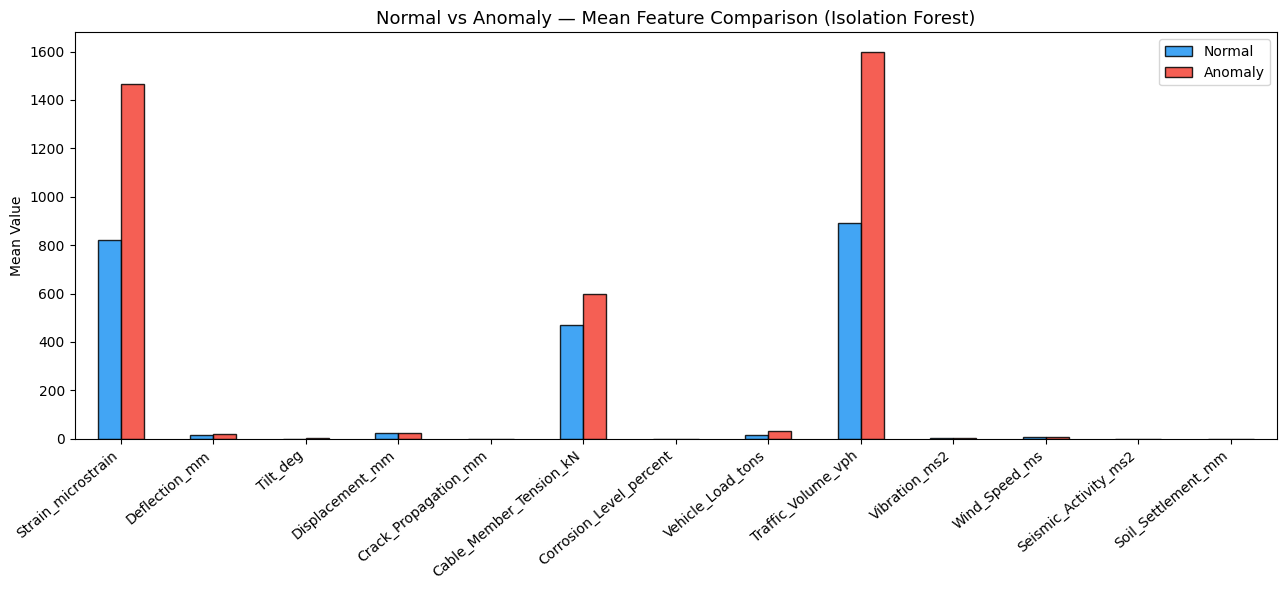

In [ ]:
normal_mean  = df[df['Anomaly'] == 0][features].mean()
anomaly_mean = df[df['Anomaly'] == 1][features].mean()

comparison_if = pd.DataFrame({'Normal': normal_mean, 'Anomaly': anomaly_mean})
comparison_if.plot(kind='bar', figsize=(13, 6),
                   color=['#2196F3', '#F44336'], edgecolor='black', alpha=0.85)
plt.title("Normal vs Anomaly — Mean Feature Comparison (Isolation Forest)", fontsize=13)
plt.ylabel("Mean Value")
plt.xticks(rotation=40, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 8.6 Isolation Forest — Feature Importance

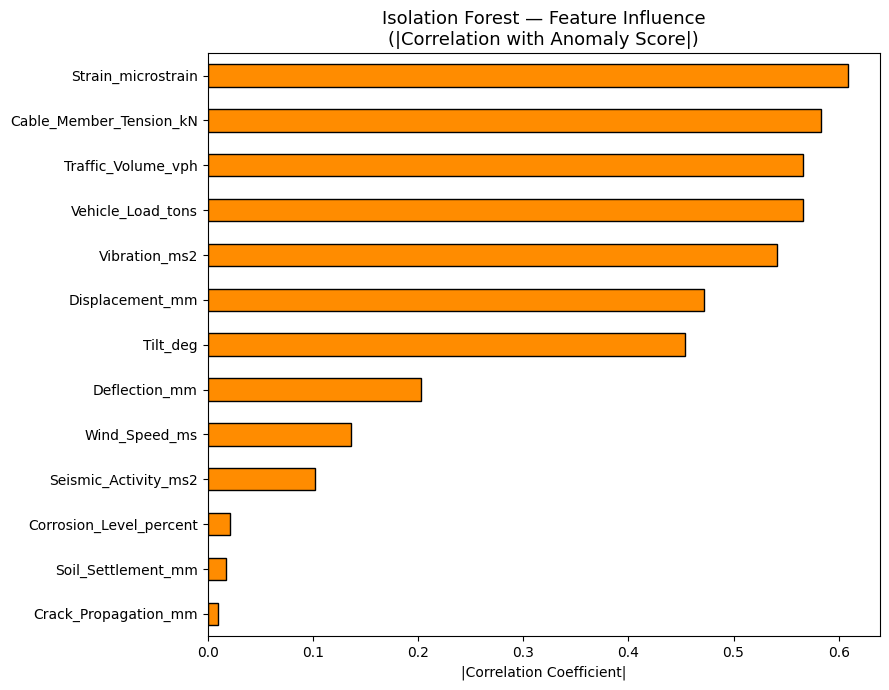

Feature influence ranking (Isolation Forest):
Strain_microstrain         0.6088
Cable_Member_Tension_kN    0.5831
Traffic_Volume_vph         0.5660
Vehicle_Load_tons          0.5659
Vibration_ms2              0.5411
Displacement_mm            0.4722
Tilt_deg                   0.4539
Deflection_mm              0.2027
Wind_Speed_ms              0.1365
Seismic_Activity_ms2       0.1018
Corrosion_Level_percent    0.0213
Soil_Settlement_mm         0.0173
Crack_Propagation_mm       0.0100
dtype: float64


In [ ]:
# Measured as absolute correlation between each feature and the anomaly score
# (a lower IF score means more anomalous, so strong correlation = high influence)
if_importance = {}
for feat in features:
    corr = np.corrcoef(X[feat], df['Anomaly_Score_IF'])[0, 1]
    if_importance[feat] = abs(corr)

if_imp_series = pd.Series(if_importance).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
if_imp_series.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title("Isolation Forest — Feature Influence\n(|Correlation with Anomaly Score|)",
          fontsize=13)
plt.xlabel("|Correlation Coefficient|")
plt.tight_layout()
plt.show()

print("Feature influence ranking (Isolation Forest):")
print(if_imp_series.sort_values(ascending=False).round(4))

### 8.7 Clusters vs Anomalies


Crosstab — Cluster vs Anomaly:
Anomaly (0=Normal, 1=Anomaly)      0     1
Cluster_Label                             
Critical                        9398  1796
Healthy                        15842   196
Moderate Stress                15800   168


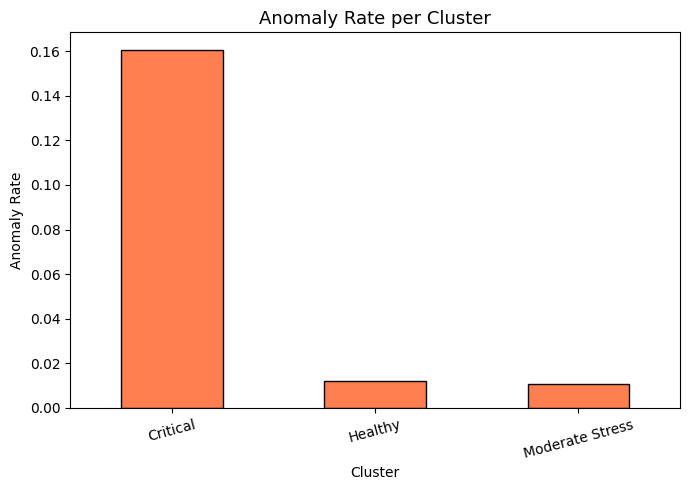

In [ ]:
print("\nCrosstab — Cluster vs Anomaly:")
print(pd.crosstab(df['Cluster_Label'], df['Anomaly'],
                  colnames=['Anomaly (0=Normal, 1=Anomaly)']))

cluster_anomaly_ratio = (df.groupby('Cluster_Label')['Anomaly']
                           .mean()
                           .sort_values(ascending=False))
cluster_anomaly_ratio.plot(kind='bar', color='coral',
                           edgecolor='black', figsize=(7, 5))
plt.title("Anomaly Rate per Cluster", fontsize=13)
plt.ylabel("Anomaly Rate")
plt.xlabel("Cluster")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# SECTION 9 — SUPERVISED LEARNING (RANDOM FOREST CLASSIFIER)

### 9.1 Create Target — SHIBased (noncircular)

In [ ]:

# Top 5% Anomaly Detection Score = anomaly event
# Not circular because Anomaly_Detection_Score is NOT one of our 13 input features
# RF learns from raw physical sensor readings to predict what the anomaly score flags

threshold    = df['Anomaly_Detection_Score'].quantile(0.95)
df['Target'] = (df['Anomaly_Detection_Score'] > threshold).astype(int)

print(f"Anomaly Detection Score threshold (95th percentile): {threshold:.4f}")
print("Target class distribution:")
print(df['Target'].value_counts())
print(f"Anomaly rate: {df['Target'].mean()*100:.1f}%")

Anomaly Detection Score threshold (95th percentile): 0.0000
Target class distribution:
Target
0    41901
1     1299
Name: count, dtype: int64
Anomaly rate: 3.0%


### 9.2 Chronological TrainTest Split (80 / 20)

In [ ]:
# Random split leaks future data into training — incorrect for time-series.
# Train on first 80% of timestamps, test on last 20%.
y         = df['Target']
split_idx = int(len(X_df) * 0.80)

X_train = X_df.iloc[:split_idx]
X_test  = X_df.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"\nTrain: {len(X_train)} rows  |  Test: {len(X_test)} rows")
print(f"Train period: {df['Timestamp'].iloc[0].date()} → "
      f"{df['Timestamp'].iloc[split_idx-1].date()}")
print(f"Test  period: {df['Timestamp'].iloc[split_idx].date()} → "
      f"{df['Timestamp'].iloc[-1].date()}")


Train: 34560 rows  |  Test: 8640 rows
Train period: 2023-01-01 → 2023-01-24
Test  period: 2023-01-25 → 2023-01-30


### 9.3 Train Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',    # corrects for class imbalance (~10% anomaly)
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

### 9.4 Predictions

In [ ]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

### 9.5 Evaluation

In [ ]:
print("=" * 55)
print("  RANDOM FOREST — EVALUATION RESULTS")
print("=" * 55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Normal', 'Anomaly']))

  RANDOM FOREST — EVALUATION RESULTS
Accuracy  : 0.9329
ROC-AUC   : 0.8967

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96      8383
     Anomaly       0.20      0.42      0.27       257

    accuracy                           0.93      8640
   macro avg       0.59      0.68      0.62      8640
weighted avg       0.96      0.93      0.94      8640



### 9.6 Confusion Matrix

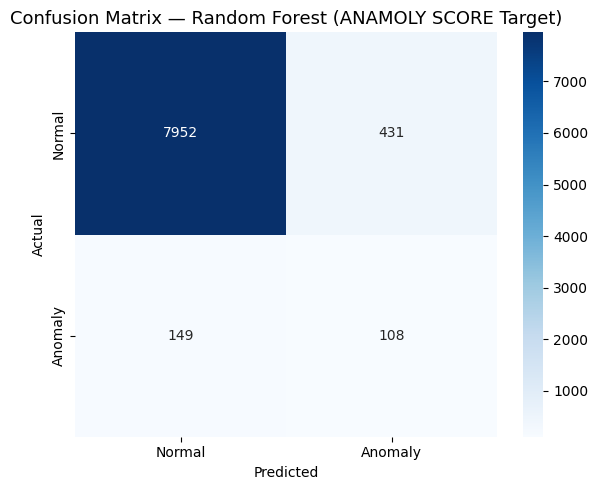

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title("Confusion Matrix — Random Forest (ANAMOLY SCORE Target)", fontsize=13)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 9.7 Feature Importance — Random Forest

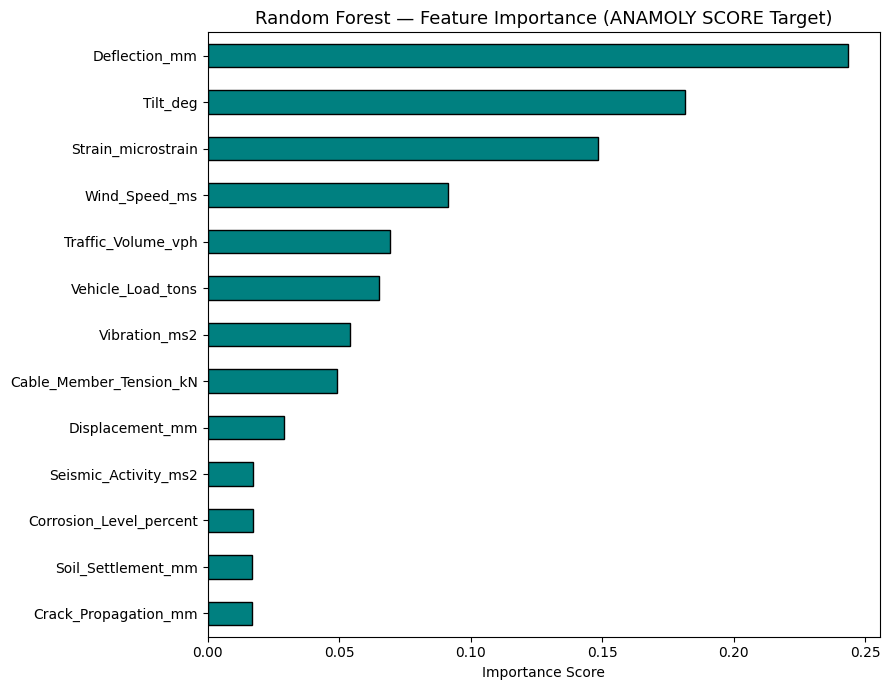

Feature importance ranking (Random Forest):
Deflection_mm              0.2435
Tilt_deg                   0.1816
Strain_microstrain         0.1485
Wind_Speed_ms              0.0914
Traffic_Volume_vph         0.0695
Vehicle_Load_tons          0.0652
Vibration_ms2              0.0542
Cable_Member_Tension_kN    0.0490
Displacement_mm            0.0290
Seismic_Activity_ms2       0.0172
Corrosion_Level_percent    0.0171
Soil_Settlement_mm         0.0169
Crack_Propagation_mm       0.0167
dtype: float64


In [ ]:
feat_imp_rf = pd.Series(rf.feature_importances_,
                         index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
feat_imp_rf.plot(kind='barh', color='teal', edgecolor='black')
plt.title("Random Forest — Feature Importance (ANAMOLY SCORE Target)", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Feature importance ranking (Random Forest):")
print(feat_imp_rf.sort_values(ascending=False).round(4))

### 9.8 Predicted Probability Over Time (Test Period)

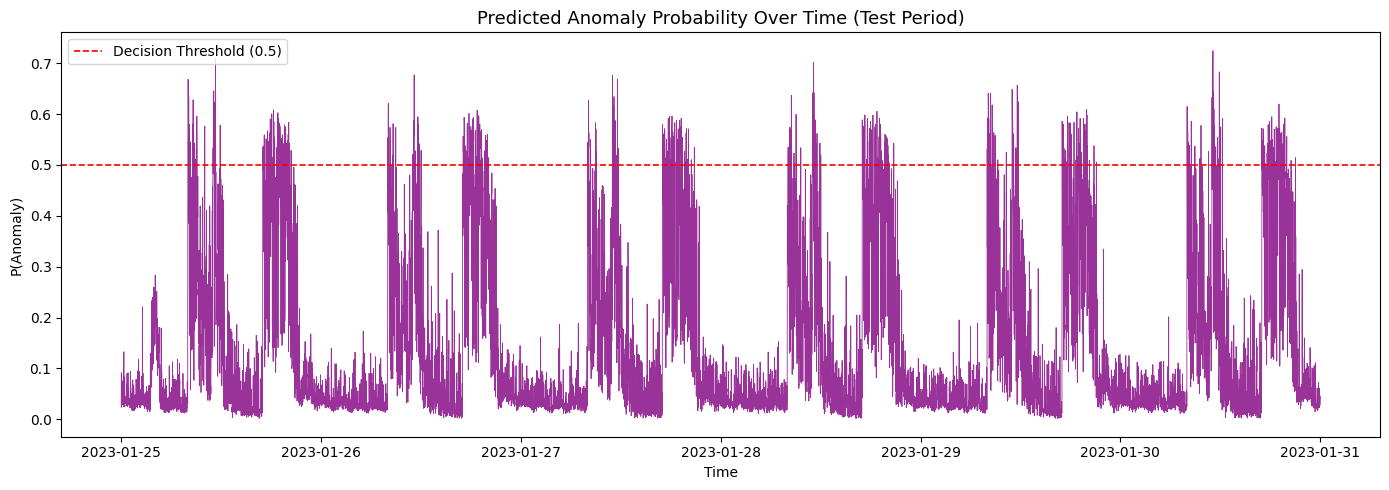

In [ ]:
test_timestamps = df['Timestamp'].iloc[split_idx:]

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps, y_proba,
         linewidth=0.6, color='purple', alpha=0.8)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.2,
            label='Decision Threshold (0.5)')
plt.title("Predicted Anomaly Probability Over Time (Test Period)", fontsize=13)
plt.xlabel("Time")
plt.ylabel("P(Anomaly)")
plt.legend()
plt.tight_layout()
plt.show()

# SECTION 10 — COMPARISON: IF vs RF vs TRUE LABELS

# Store RF predictions back into df for the test window
df['Predicted_RF']    = np.nan
df['Predicted_Proba'] = np.nan
df.loc[X_test.index, 'Predicted_RF']    = y_pred
df.loc[X_test.index, 'Predicted_Proba'] = y_proba

test_df = df.loc[X_test.index].copy()

### 10.1 Agreement Percentages

In [ ]:
agreement_if = (df['Anomaly'] == df['Target']).mean() * 100
agreement_rf = (test_df['Predicted_RF'] == test_df['Target']).mean() * 100
print(f"Agreement — Isolation Forest vs SHI Target (full dataset): {agreement_if:.2f}%")
print(f"Agreement — Random Forest vs SHI Target (test set)       : {agreement_rf:.2f}%")

Agreement — Isolation Forest vs SHI Target (full dataset): 92.79%
Agreement — Random Forest vs SHI Target (test set)       : 93.29%


### 10.2 Crosstabs

In [ ]:
print("\nCrosstab — Isolation Forest vs True Labels:")
print(pd.crosstab(df['Anomaly'], df['Target'],
                  rownames=['Isolation Forest'],
                  colnames=['SHI Target']))

print("\nCrosstab — Random Forest vs True Labels (test set):")
print(pd.crosstab(test_df['Target'], test_df['Predicted_RF'],
                  rownames=['SHI Target'],
                  colnames=['RF Predicted']))


Crosstab — Isolation Forest vs True Labels:
SHI Target            0     1
Isolation Forest             
0                 39913  1127
1                  1988   172

Crosstab — Random Forest vs True Labels (test set):
RF Predicted   0.0  1.0
SHI Target             
0             7952  431
1              149  108


### 10.3 Overlap

In [ ]:
overlap = ((df['Anomaly'] == 1) & (df['Target'] == 1)).sum()
print(f"\nAnomalies flagged by BOTH Isolation Forest AND SHI Target: {overlap}")


Anomalies flagged by BOTH Isolation Forest AND SHI Target: 172


### 10.4 SidebySide Feature Importance: IF vs RF

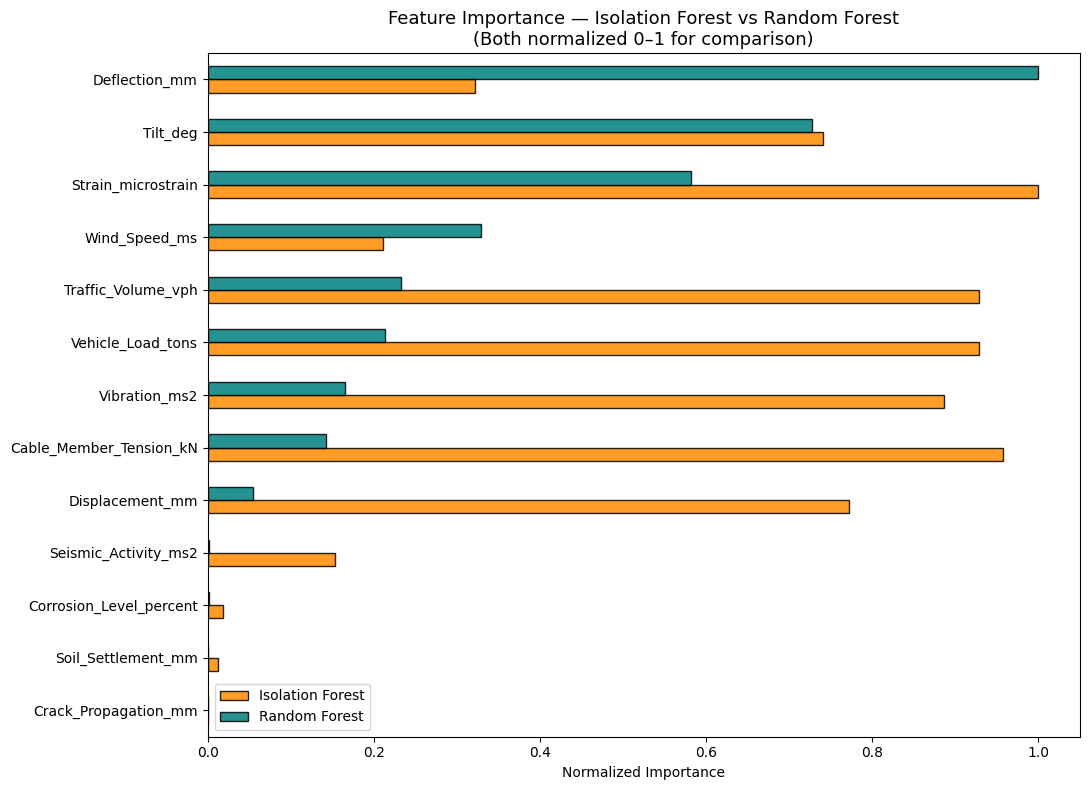

In [ ]:
# Normalize both to 0–1 for fair visual comparison
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

if_imp_norm = normalize(if_imp_series)
rf_imp_norm = normalize(feat_imp_rf)

comparison_imp = pd.DataFrame({
    'Isolation Forest': if_imp_norm,
    'Random Forest'   : rf_imp_norm,
}).sort_values('Random Forest', ascending=True)

comparison_imp.plot(kind='barh', figsize=(11, 8),
                    color=['darkorange', 'teal'],
                    edgecolor='black', alpha=0.85)
plt.title("Feature Importance — Isolation Forest vs Random Forest\n"
          "(Both normalized 0–1 for comparison)", fontsize=13)
plt.xlabel("Normalized Importance")
plt.tight_layout()
plt.show()

### 10.5 Timeline: All Three Methods Side by Side

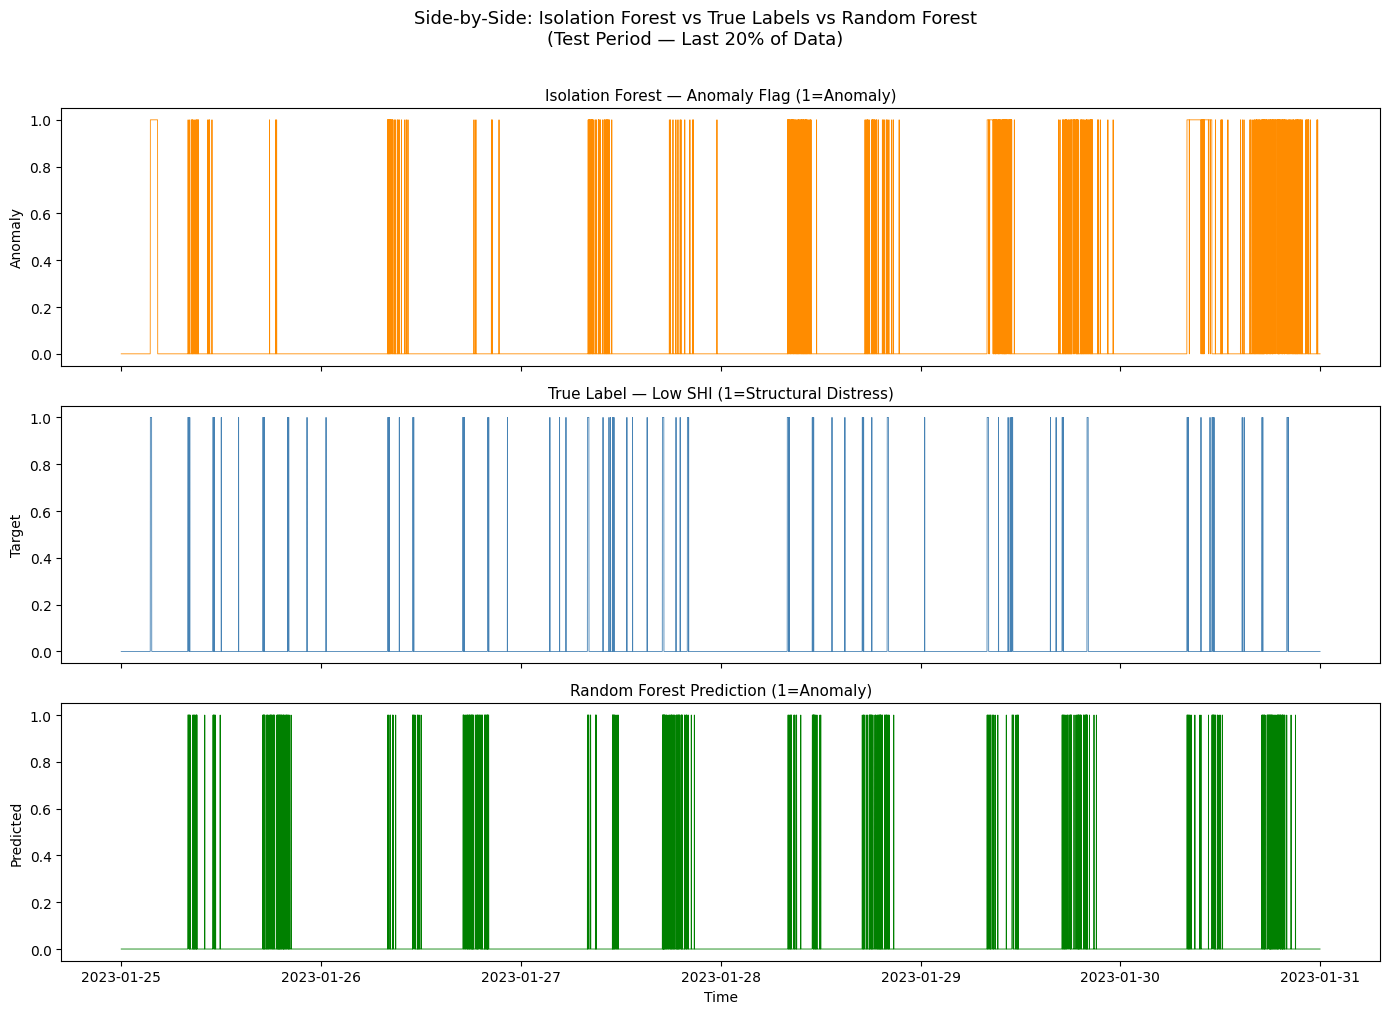

Maintenance Decision Distribution:
Decision
GREEN  — No Action              40577
YELLOW — Monitor Closely         2283
ORANGE — Schedule Inspection      340
Name: count, dtype: int64


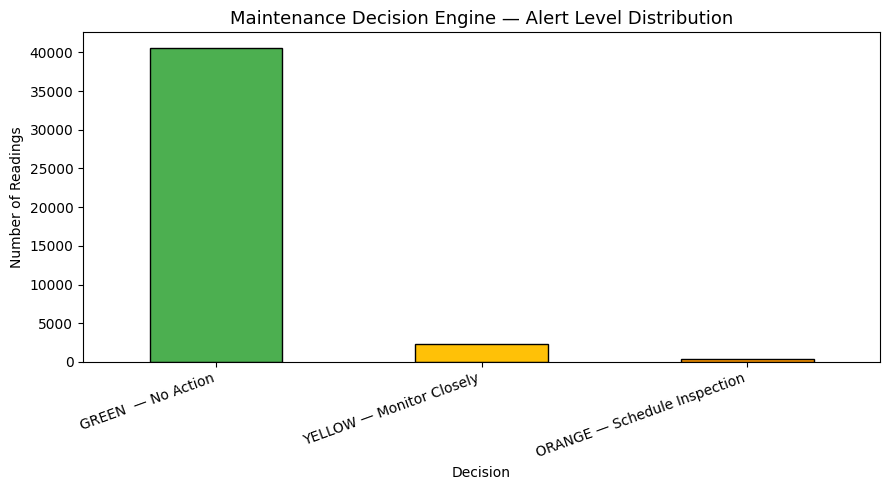


Total RED alerts: 0

Sample RED alert readings:
Empty DataFrame
Columns: [Strain_microstrain, Deflection_mm, Tilt_deg, Displacement_mm, Crack_Propagation_mm, Cable_Member_Tension_kN, Corrosion_Level_percent, Vehicle_Load_tons, Traffic_Volume_vph, Vibration_ms2, Wind_Speed_ms, Seismic_Activity_ms2, Soil_Settlement_mm, Anomaly, Target, Decision]
Index: []


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(test_timestamps, test_df['Anomaly'],
             linewidth=0.6, color='darkorange')
axes[0].set_title("Isolation Forest — Anomaly Flag (1=Anomaly)", fontsize=11)
axes[0].set_ylabel("Anomaly")

axes[1].plot(test_timestamps, test_df['Target'],
             linewidth=0.6, color='steelblue')
axes[1].set_title("True Label — Low SHI (1=Structural Distress)", fontsize=11)
axes[1].set_ylabel("Target")

axes[2].plot(test_timestamps, test_df['Predicted_RF'],
             linewidth=0.6, color='green')
axes[2].set_title("Random Forest Prediction (1=Anomaly)", fontsize=11)
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Time")

plt.suptitle("Side-by-Side: Isolation Forest vs True Labels vs Random Forest\n"
             "(Test Period — Last 20% of Data)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# SECTION 11 — MAINTENANCE DECISION ENGINE
# Combines 3 independent signals into a single actionable alert:
#   Signal 1 — Isolation Forest flag (unsupervised)
#   Signal 2 — Random Forest prediction (supervised)
#   Signal 3 — Dataset Maintenance_Alert column
#
# Score 0 → GREEN  (no action)
# Score 1 → YELLOW (monitor)
# Score 2 → ORANGE (schedule inspection)
# Score 3 → RED    (immediate action)

df['Maint_Alert_filled'] = df['Maintenance_Alert'].ffill().bfill()

def maintenance_decision(row):
    score = 0
    if row['Anomaly'] == 1:
        score += 1
    if row.get('Predicted_RF') == 1:
        score += 1
    if row['Maint_Alert_filled'] == 1:
        score += 1

    if score == 0:   return 'GREEN  — No Action'
    elif score == 1: return 'YELLOW — Monitor Closely'
    elif score == 2: return 'ORANGE — Schedule Inspection'
    else:            return 'RED    — Immediate Action Required'

df['Decision'] = df.apply(maintenance_decision, axis=1)

print("Maintenance Decision Distribution:")
print(df['Decision'].value_counts())

# Plot
decision_counts = df['Decision'].value_counts()
colors_map = {
    'GREEN  — No Action'              : '#4CAF50',
    'YELLOW — Monitor Closely'        : '#FFC107',
    'ORANGE — Schedule Inspection'    : '#FF9800',
    'RED    — Immediate Action Required': '#F44336',
}
bar_colors = [colors_map.get(k, 'grey') for k in decision_counts.index]

plt.figure(figsize=(9, 5))
decision_counts.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.title("Maintenance Decision Engine — Alert Level Distribution", fontsize=13)
plt.ylabel("Number of Readings")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Sample RED alerts
red_alerts = df[df['Decision'] == 'RED    — Immediate Action Required']
print(f"\nTotal RED alerts: {len(red_alerts)}")
print("\nSample RED alert readings:")
print(red_alerts[features + ['Anomaly', 'Target', 'Decision']].head(5).to_string())

In [ ]:
# ============================================================
# SECTION 11 — EXPORT 500-ROW SAMPLE FOR DASHBOARD
# Add this cell at the END of your SHM_Bridge_v3 notebook
# ============================================================
import json
# Columns to export
export_cols = [
'Timestamp',
# 13 domain-selected features
'Strain_microstrain',
'Deflection_mm',
'Tilt_deg',
'Displacement_mm',
'Crack_Propagation_mm',
'Cable_Member_Tension_kN',
'Corrosion_Level_percent',
'Vehicle_Load_tons',
'Traffic_Volume_vph',
'Vibration_ms2',
'Wind_Speed_ms',
'Seismic_Activity_ms2',
'Soil_Settlement_mm',
# ML model outputs
'Anomaly_Score_IF', # Isolation Forest score (negative = anomalous)
'Anomaly', # IF flag: 1 = anomaly, 0 = normal
'Predicted_Proba', # Random Forest anomaly probability (0-1)
'Predicted_RF', # RF flag: 1 = anomaly, 0 = normal
'Cluster_Label', # K-Means: Healthy / Moderate Stress / Critical
'Target', # Ground truth label (from Anomaly_Detection_Score)
]
# Only keep rows where ALL columns are available
# (Predicted_RF and Predicted_Proba only exist for test period rows)
# So we take 500 rows from the TEST period (last 20% = Jan 25-30)
split_idx = int(len(df) * 0.80)
df_test_period = df.iloc[split_idx:].copy()
# Drop rows with any missing export columns
df_export = df_test_period[export_cols].dropna().reset_index(drop=True)
# Take 500 rows — sample evenly across the test period to cover all phases
step = max(1, len(df_export) // 500)
df_sample = df_export.iloc[::step].head(500).copy()
# Convert Timestamp to string for JSON serialization
df_sample['Timestamp'] = df_sample['Timestamp'].astype(str)
# Convert to list of dicts
records = df_sample.to_dict(orient='records')
# Round floats to 4 decimal places to keep file small
for row in records:
for k, v in row.items():
if isinstance(v, float):
row[k] = round(v, 4)
# Save to JSON
output_path = '/content/drive/MyDrive/shm_sample.json'
with open(output_path, 'w') as f:
json.dump(records, f)
print(f" Exported {len(records)} rows to: {output_path}")
print(f" Columns: {list(df_sample.columns)}")
print(f" Anomaly rate in sample: {df_sample['Anomaly'].mean()*100:.1f}%")
print(f" RF flagged rate: {df_sample['Predicted_RF'].mean()*100:.1f}%")
print(f"\n Cluster breakdown:")
print(df_sample['Cluster_Label'].value_counts().to_string())
print(f"\n Download from Google Drive: shm_sample.json")
print(f" Place it in the SAME FOLDER as bridge_shm_dashboard_v3.html")
# Also download directly in Colab if you prefer:
from google.colab import files
files.download(output_path)

IndentationError: expected an indented block after 'for' statement on line 46 (2262152704.py, line 47)